# Multimodal Deep Learning cho Xơ vữa Động mạch Cảnh

## 1 · Thư viện, seed và thiết bị

In [55]:
import math, random, os, json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report, roc_curve, recall_score)
import matplotlib
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

def get_device():
    # Thu chay that tren CUDA; neu build torch khong khop GPU -> CPU
    if torch.cuda.is_available():
        try:
            _ = torch.zeros(8, device='cuda') @ torch.zeros(8, 8, device='cuda')
            torch.cuda.synchronize(); return torch.device('cuda')
        except Exception as e:
            print(f'GPU khong tuong thich ({type(e).__name__}). Chuyen CPU. '
                  f'De dung GPU: Settings > Accelerator doi loai GPU (T4<->P100) roi Restart & Run All.')
            return torch.device('cpu')
    return torch.device('cpu')

DEVICE = get_device()

# Cau hinh chung
IMAGE_SIZE = 160        # RGB; giam con 128 neu chay CPU cho nhanh
EPOCHS     = 15
BATCH_SIZE = 8
print('DEVICE =', DEVICE, '| IMAGE_SIZE =', IMAGE_SIZE)
if DEVICE.type == 'cpu':
    IMAGE_SIZE = min(IMAGE_SIZE, 128)
    print('(CPU) giam IMAGE_SIZE =', IMAGE_SIZE)

DEVICE = cuda | IMAGE_SIZE = 160


## 2 · Tự dò dữ liệu (Kaggle `/kaggle/input` hoặc thư mục cục bộ) và nạp CSV

In [56]:
def autodetect_paths():
    roots = [Path('/kaggle/input'), Path('.'), Path('/home/jupyter-thinc/Learning/IT2039.CH201')]
    csv_path, image_root = None, None
    for root in roots:
        if not root.exists():
            continue
        if csv_path is None:
            for name in ['carotid_clinical_dataset_300cases.csv', 'carotid_gold_ratio_300cases.csv']:
                hits = list(root.rglob(name))
                if hits: csv_path = hits[0]; break
            if csv_path is None:
                hits = [p for p in root.rglob('*.csv') if 'carotid' in p.name.lower()]
                if hits: csv_path = hits[0]
        if image_root is None:
            for p in root.rglob('*'):
                if p.is_dir() and p.name.upper() == 'CAROTID_IMAGES':
                    image_root = p; break
        if csv_path and image_root: break
    return csv_path, image_root

CSV_PATH, IMAGE_ROOT = autodetect_paths()
assert CSV_PATH is not None, 'Khong tim thay CSV carotid_*. Hay Add Data tren Kaggle.'
assert IMAGE_ROOT is not None, 'Khong tim thay thu muc CAROTID_IMAGES.'
OUTPUT_DIR = Path('/kaggle/working/outputs') if Path('/kaggle/working').exists() else Path('outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('CSV_PATH   =', CSV_PATH)
print('IMAGE_ROOT =', IMAGE_ROOT, '| so anh:', sum(1 for _ in IMAGE_ROOT.rglob('*.png')))
df = pd.read_csv(CSV_PATH)
print('CSV shape  =', df.shape)
df.head()

CSV_PATH   = /kaggle/input/datasets/tricd16/clinical-carotid-dataset-v3/clinical_carotid_dataset_v3/carotid_clinical_dataset_300cases.csv
IMAGE_ROOT = /kaggle/input/datasets/tricd16/clinical-carotid-dataset-v3/clinical_carotid_dataset_v3/CAROTID_IMAGES | so anh: 680
CSV shape  = (300, 15)


,Patient_ID,Age,Sex,Lp(a)_mg_dL,ApoB_mg_dL,LDL_C_mg_dL,Triglyceride_mg_dL,Total_Cholesterol_mg_dL,Non_HDL_mg_dL,IMT_mm,Plaque_present,Plaque_echogenicity,Baseline_Risk_Score,Baseline_Risk_Category,Associated_Images
0,P001,59,Male,10.0,97.7,157.6,123.4,195.3,150.0,0.710,0,NaN,0.49,Low,P001_IMT.png
1,P002,53,Male,37.6,128.0,159.7,152.8,185.8,139.4,0.698,0,NaN,0.11,Low,P002_IMT.png
2,P003,61,Female,18.2,140.4,146.0,86.0,187.1,135.2,0.733,1,Low,0.14,Low,"P003_IMT.png,P003_CCA_L1.png,P003_CCA_L2.png,P..."
3,P004,70,Female,38.2,101.5,101.4,71.1,140.7,102.2,0.879,1,Intermediate,0.00,Low,"P004_IMT.png,P004_CCA_L1.png,P004_CCA_L2.png,P..."
4,P005,52,Female,17.2,99.2,170.8,70.0,186.8,156.9,0.637,0,NaN,0.08,Low,P005_IMT.png


## 3 · Tự dò các cột quan trọng

In [57]:
def find_col(frame, candidates):
    norm = {str(c).strip().lower(): c for c in frame.columns}
    for cand in candidates:
        if cand.strip().lower() in norm: return norm[cand.strip().lower()]
    return None

id_col          = find_col(df, ['patient_id','id','case_id','subject_id'])
target_col      = find_col(df, ['plaque_present','target','label'])
risk_score_col  = find_col(df, ['baseline_risk_score','risk_score'])
risk_cat_col    = find_col(df, ['baseline_risk_category','risk_category'])
echo_col        = find_col(df, ['plaque_echogenicity','echogenicity'])
image_list_col  = find_col(df, ['associated_images','image_files','images'])
sex_col         = find_col(df, ['sex','gender'])
assert target_col is not None, 'Thieu cot Plaque_present'
for n,v in dict(id=id_col,target=target_col,risk_score=risk_score_col,risk_cat=risk_cat_col,
                echo=echo_col,image_list=image_list_col,sex=sex_col).items():
    print(f'{n:12s}= {v}')

id          = Patient_ID
target      = Plaque_present
risk_score  = Baseline_Risk_Score
risk_cat    = Baseline_Risk_Category
echo        = Plaque_echogenicity
image_list  = Associated_Images
sex         = Sex


## 4 · Tiền xử lý dữ liệu lâm sàng (z-score, mã hoá giới tính)

In [58]:
def coerce_sex(series):
    m = {'m':1.,'male':1.,'1':1.,1:1., 'f':0.,'female':0.,'0':0.,0:0.}
    return pd.Series([m.get(v, np.nan) for v in series.fillna('u').astype(str).str.strip().str.lower()],
                     index=series.index, dtype='float32')

tab_hint = ['age','sex','ldl-c','ldl_c','ldl','apob','lp(a)','lpa','triglyceride',
            'total cholesterol','total_cholesterol','non-hdl','non_hdl','imt']
excluded = {str(x).strip().lower() for x in [target_col,risk_score_col,risk_cat_col,echo_col,image_list_col,id_col] if x}
selected = []
for c in df.columns:
    n = str(c).strip().lower()
    if n in excluded: continue
    if pd.api.types.is_numeric_dtype(df[c]) or n in tab_hint or n.replace(' ','') in [h.replace(' ','') for h in tab_hint]:
        selected.append(c)
selected = list(dict.fromkeys(selected))

work = df.copy()
if sex_col: work[sex_col] = coerce_sex(work[sex_col])
if risk_score_col: work[risk_score_col] = pd.to_numeric(work[risk_score_col], errors='coerce')
if risk_cat_col:   work[risk_cat_col]   = work[risk_cat_col].astype(str)
if echo_col:       work[echo_col]       = work[echo_col].astype(str)

feature_columns = [c for c in selected if c not in {target_col,risk_score_col,risk_cat_col,echo_col}]
assert feature_columns, 'Khong co feature tabular'
# Chuan hoa z-score (thong ke tinh tren toan bo; se fit lai theo train o phan ablation)
feature_means = work[feature_columns].mean(numeric_only=True)
feature_stds  = work[feature_columns].std(numeric_only=True).replace(0, 1.0)
work[feature_columns] = work[feature_columns].fillna(feature_means)
work[feature_columns] = (work[feature_columns] - feature_means) / feature_stds
work[target_col] = work[target_col].astype(int)
work = work.reset_index(drop=True)
print('Feature tabular (%d):' % len(feature_columns), feature_columns)

Feature tabular (9): ['Age', 'Sex', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL', 'Total_Cholesterol_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm']


## 5 · Định tuyến ảnh theo nhiệm vụ (chống rò rỉ)

`resolve_images(row)` trả về đường dẫn ảnh của bệnh nhân; `filter_kind` tách **IMT** và **CCA**.
- Nhiệm vụ **plaque / risk**: chỉ dùng **IMT** (1 ảnh/ca) → không thể "đếm ảnh".
- Nhiệm vụ **echogenicity**: dùng **CCA** (mặt cắt ngang mảng).

In [59]:
image_index = defaultdict(list)
for p in IMAGE_ROOT.rglob('*'):
    if p.is_file():
        image_index[p.name.lower()].append(p)

def resolve_images(row):
    raw = row[image_list_col] if (image_list_col and image_list_col in row.index) else None
    if raw is None or (isinstance(raw, float) and pd.isna(raw)): return []
    text = str(raw).strip().strip('[]')
    out, seen = [], set()
    for chunk in text.replace(';',',').replace('|',',').split(','):
        tok = chunk.strip().strip('\'"').strip()
        if not tok: continue
        for cand in [IMAGE_ROOT/tok, IMAGE_ROOT/Path(tok).name] + image_index.get(Path(tok).name.lower(), []):
            if Path(cand).exists():
                r = str(Path(cand).resolve())
                if r not in seen: seen.add(r); out.append(Path(cand)); break
    return out

def filter_kind(paths, kind):
    if kind == 'all': return paths
    key = '_imt' if kind == 'imt' else '_cca_'
    return [p for p in paths if key in p.name.lower()]

# kiem tra nhanh
_n = work.iloc[[0]].apply(lambda r: len(filter_kind(resolve_images(r), 'imt')), axis=1).iloc[0]
print('Anh IMT cua ca dau tien:', _n)

Anh IMT cua ca dau tien: 1


## 6 · Nhãn phân loại, chia train/val/test phân tầng, chuẩn hoá điểm nguy cơ

In [60]:
# Echo chi tren ca co plaque (loai lop 'unknown' cua control)
if echo_col:
    echo_vals = sorted(work.loc[work[target_col]==1, echo_col].unique().tolist())
    echo_to_idx = {v:i for i,v in enumerate(echo_vals)}
else:
    echo_vals, echo_to_idx = [], {}
if risk_cat_col:
    rc_vals = sorted(work[risk_cat_col].unique().tolist())
    rc_to_idx = {v:i for i,v in enumerate(rc_vals)}
else:
    rc_vals, rc_to_idx = [], {}

train_df, temp_df = train_test_split(work, test_size=0.30, random_state=SEED, stratify=work[target_col])
val_df, test_df   = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df[target_col])

rs_mean = float(train_df[risk_score_col].mean()) if risk_score_col else 0.0
rs_std  = float(train_df[risk_score_col].std()) if risk_score_col else 1.0
rs_std  = rs_std if rs_std != 0 else 1.0

print('train/val/test =', len(train_df), len(val_df), len(test_df))
print('Echo classes (chi ca plaque):', echo_vals)
print('Risk categories:', rc_vals, '(luu y: rat lech lop)')

train/val/test = 210 45 45
Echo classes (chi ca plaque): ['High', 'Intermediate', 'Low']
Risk categories: ['Low', 'Moderate'] (luu y: rat lech lop)


## 7 · Dataset đa phương thức (định tuyến ảnh + Set-Attention mask)

In [61]:
class MultimodalDataset(Dataset):
    def __init__(self, frame, image_kind='imt', max_images=1):
        self.frame = frame.reset_index(drop=True)
        self.image_kind = image_kind
        self.max_images = max_images

    def __len__(self): return len(self.frame)

    def _load(self, path):
        img = Image.open(path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        t = torch.from_numpy(np.asarray(img, np.float32)/255.).permute(2,0,1)
        return (t - 0.5) / 0.5

    def __getitem__(self, i):
        row = self.frame.iloc[i]
        feats = torch.tensor(row[feature_columns].astype(float).values, dtype=torch.float32)
        label = torch.tensor(float(row[target_col]), dtype=torch.float32)
        paths = filter_kind(resolve_images(row), self.image_kind)[:self.max_images]
        if len(paths) == 0:
            imgs = torch.zeros((self.max_images,3,IMAGE_SIZE,IMAGE_SIZE)); mask = torch.zeros(self.max_images)
        else:
            lst = [self._load(p) for p in paths]; mask = torch.ones(len(lst))
            while len(lst) < self.max_images:
                lst.append(torch.zeros_like(lst[0])); mask = torch.cat([mask, torch.zeros(1)])
            imgs = torch.stack(lst, 0)
        s = {'features':feats, 'images':imgs, 'image_mask':mask, 'label':label}
        if risk_score_col:
            s['risk_score'] = torch.tensor(((float(row[risk_score_col])-rs_mean)/rs_std), dtype=torch.float32)
        if risk_cat_col:
            s['risk_cat'] = torch.tensor(rc_to_idx[str(row[risk_cat_col])], dtype=torch.long)
        if echo_col and int(row[target_col])==1 and str(row[echo_col]) in echo_to_idx:
            s['echo'] = torch.tensor(echo_to_idx[str(row[echo_col])], dtype=torch.long)
        return s

def collate(batch):
    out = {'features':torch.stack([b['features'] for b in batch]),
           'images':torch.stack([b['images'] for b in batch]),
           'image_mask':torch.stack([b['image_mask'] for b in batch]),
           'label':torch.stack([b['label'] for b in batch])}
    for k in ['risk_score','risk_cat','echo']:
        if all(k in b for b in batch):
            out[k] = torch.stack([b[k] for b in batch])
    return out
print('Dataset OK')

Dataset OK


## 8 · Kiến trúc: CNN + MLP + Set-Attention + head theo nhiệm vụ

In [62]:
class SimpleCNNEncoder(nn.Module):
    def __init__(self, out_dim=128):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3,32,3,2,1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(32,64,3,1,1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2,2),
            nn.Conv2d(64,128,3,1,1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d(1))
        self.proj = nn.Sequential(nn.Flatten(), nn.Linear(128,out_dim), nn.ReLU(True), nn.Dropout(0.2))
    def forward_features(self, x): return self.features(x)
    def forward(self, x): return self.proj(self.features(x))

class TabularEncoder(nn.Module):
    def __init__(self, in_dim, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim,out_dim), nn.ReLU(True), nn.Dropout(0.2),
                                 nn.Linear(out_dim,out_dim), nn.ReLU(True))
    def forward(self, x): return self.net(x)

class AttentionPool(nn.Module):
    # Gop K anh (K thay doi) -> 1 vector, co mask (Attention-MIL)
    def __init__(self, dim, hidden=64):
        super().__init__()
        self.attn = nn.Sequential(nn.Linear(dim,hidden), nn.Tanh(), nn.Linear(hidden,1))
    def forward(self, feats, mask):                       # feats[B,K,D], mask[B,K] float
        scores = self.attn(feats).squeeze(-1)
        scores = scores.masked_fill(mask < 0.5, torch.finfo(scores.dtype).min)
        w = torch.softmax(scores, dim=1) * mask
        denom = w.sum(1, keepdim=True).clamp_min(1e-6)
        pooled = ((w/denom).unsqueeze(-1) * feats).sum(1)
        return pooled * (mask.sum(1, keepdim=True) > 0).float()

class MultimodalTaskModel(nn.Module):
    def __init__(self, tabular_dim, task_type, embed=128, fusion=128, num_classes=None):
        super().__init__()
        self.task_type = task_type
        self.image_encoder = SimpleCNNEncoder(embed)
        self.tabular_encoder = TabularEncoder(tabular_dim, embed)
        self.pool = AttentionPool(embed)
        self.fusion = nn.Sequential(nn.Linear(embed*2, fusion), nn.ReLU(True), nn.Dropout(0.25))
        if task_type in {'binary','regression'}: self.head = nn.Linear(fusion, 1)
        elif task_type == 'multiclass':
            assert num_classes and num_classes >= 2; self.head = nn.Linear(fusion, num_classes)
        else: raise ValueError(task_type)
    def forward(self, features, images, image_mask=None):
        B,K,C,H,W = images.shape
        emb = self.image_encoder(images.view(B*K,C,H,W)).view(B,K,-1)
        if image_mask is None: image_mask = torch.ones(B,K, device=images.device)
        img_vec = self.pool(emb, image_mask)
        fused = self.fusion(torch.cat([img_vec, self.tabular_encoder(features)], -1))
        out = self.head(fused)
        return out.squeeze(-1) if self.task_type in {'binary','regression'} else out
print('Models OK')

Models OK


## 9 · Đăng ký nhiệm vụ (định tuyến ảnh) và tạo loader

In [63]:
TASKS = {
  'plaque':        dict(task_type='binary',     kind='imt', max_images=1, num_classes=None,
                        frames=(train_df, val_df, test_df)),
  'risk_score':    dict(task_type='regression', kind='imt', max_images=1, num_classes=None,
                        frames=(train_df, val_df, test_df)) if risk_score_col else None,
  'risk_category': dict(task_type='multiclass', kind='imt', max_images=1, num_classes=len(rc_vals),
                        frames=(train_df, val_df, test_df)) if len(rc_vals)>=2 else None,
  # echo: chi ca co plaque
  'echogenicity':  dict(task_type='multiclass', kind='cca', max_images=4, num_classes=len(echo_vals),
                        frames=(train_df[train_df[target_col]==1], val_df[val_df[target_col]==1],
                                test_df[test_df[target_col]==1])) if len(echo_vals)>=2 else None,
}
TASKS = {k:v for k,v in TASKS.items() if v is not None}

def make_loaders(task):
    cfg = TASKS[task]; tr,va,te = cfg['frames']
    dss = [MultimodalDataset(f, cfg['kind'], cfg['max_images']) for f in (tr,va,te)]
    if task == 'plaque':                       # can bang lop bang WeightedRandomSampler
        cc = tr[target_col].value_counts().to_dict()
        w = tr[target_col].map(lambda l: 1.0/cc[l]).values
        sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), len(w), replacement=True)
        ltr = DataLoader(dss[0], batch_size=BATCH_SIZE, sampler=sampler, collate_fn=collate)
    else:
        ltr = DataLoader(dss[0], batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate)
    lva = DataLoader(dss[1], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    lte = DataLoader(dss[2], batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
    return ltr, lva, lte

def build_model(task):
    cfg = TASKS[task]
    return MultimodalTaskModel(len(feature_columns), cfg['task_type'], num_classes=cfg['num_classes']).to(DEVICE)

print('Nhiem vu se huan luyen:', list(TASKS.keys()))

Nhiem vu se huan luyen: ['plaque', 'risk_score', 'risk_category', 'echogenicity']


## 10 · Hàm mất mát, đánh giá và huấn luyện (checkpoint tốt nhất theo metric riêng)

In [64]:
bce = nn.BCEWithLogitsLoss(); smoothl1 = nn.SmoothL1Loss(); ce = nn.CrossEntropyLoss()

def target_of(task, batch):
    return {'plaque':'label','risk_score':'risk_score','risk_category':'risk_cat','echogenicity':'echo'}[task]

def forward_batch(model, batch, task):
    y = batch[target_of(task, batch)].to(DEVICE)
    out = model(batch['features'].to(DEVICE), batch['images'].to(DEVICE), batch['image_mask'].to(DEVICE))
    return out, y

def loss_of(task, out, y):
    if task=='plaque': return bce(out, y)
    if task=='risk_score': return smoothl1(out, y)
    return ce(out, y)

@torch.no_grad()
def evaluate_task(model, loader, task):
    model.eval(); T,P,PB = [],[],[]
    for b in loader:
        out,y = forward_batch(model,b,task)
        if task=='plaque':
            pb=torch.sigmoid(out); P+= (pb>=0.5).long().cpu().tolist(); PB+=pb.cpu().tolist(); T+=y.long().cpu().tolist()
        elif task=='risk_score':
            P+=(out*rs_std+rs_mean).cpu().tolist(); T+=(y*rs_std+rs_mean).cpu().tolist()
        else:
            P+=out.argmax(-1).cpu().tolist(); T+=y.long().cpu().tolist()
    if task=='plaque':
        auc=roc_auc_score(T,PB) if len(set(T))>1 else float('nan')
        return dict(acc=accuracy_score(T,P), f1=f1_score(T,P,zero_division=0), auc=auc,
                    sens=recall_score(T,P,pos_label=1,zero_division=0),
                    spec=recall_score(T,P,pos_label=0,zero_division=0),
                    primary=(auc if not math.isnan(auc) else accuracy_score(T,P)),
                    targets=T, preds=P, probs=PB)
    if task=='risk_score':
        T,P=np.array(T),np.array(P); mae=float(np.abs(P-T).mean()); rmse=float(np.sqrt(((P-T)**2).mean()))
        return dict(mae=mae, rmse=rmse, primary=-mae, targets=T.tolist(), preds=P.tolist())
    return dict(acc=accuracy_score(T,P), f1_macro=f1_score(T,P,average='macro',zero_division=0),
                primary=f1_score(T,P,average='macro',zero_division=0), targets=T, preds=P)

def train_task(task, epochs=EPOCHS):
    model = build_model(task); ltr,lva,lte = make_loaders(task)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', patience=2, factor=0.5)
    best, best_path, hist = -1e9, OUTPUT_DIR/f'best_{task}_model.pt', []
    for ep in range(1, epochs+1):
        model.train(); tot=0; n=0
        for b in ltr:
            opt.zero_grad(set_to_none=True)
            out,y = forward_batch(model,b,task); l = loss_of(task,out,y)
            l.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0); opt.step()
            tot+=l.item()*y.size(0); n+=y.size(0)
        m = evaluate_task(model, lva, task); sch.step(m['primary'])
        if m['primary']>best:
            best=m['primary']
            torch.save({'model_state_dict':model.state_dict(),'task':task,
                        'feature_columns':feature_columns,'feature_means':feature_means.to_dict(),
                        'feature_stds':feature_stds.to_dict(),'rs_mean':rs_mean,'rs_std':rs_std,
                        'echo_vals':echo_vals,'rc_vals':rc_vals,
                        'cfg':{k:TASKS[task][k] for k in ['task_type','kind','max_images','num_classes']}},
                       best_path)
        show = {k:round(v,4) for k,v in m.items() if isinstance(v,(int,float))}
        print(f'[{task}] ep{ep:02d} train_loss={tot/max(n,1):.4f}', show)
        hist.append(dict(epoch=ep, train_loss=tot/max(n,1), **{k:v for k,v in m.items() if isinstance(v,(int,float))}))
    return best_path, pd.DataFrame(hist)
print('Train/eval OK')

Train/eval OK


## 11 · Huấn luyện tất cả nhiệm vụ

In [65]:
histories = {}
for task in TASKS:
    print('='*60, '\n', task); print('='*60)
    _, h = train_task(task, epochs=EPOCHS)
    histories[task] = h
print('\nHoan tat. Checkpoint luu tai', OUTPUT_DIR)

 plaque
[plaque] ep01 train_loss=0.6879 {'acc': 0.7778, 'f1': 0.6429, 'auc': np.float64(0.7788), 'sens': 0.6429, 'spec': 0.8387, 'primary': np.float64(0.7788)}
[plaque] ep02 train_loss=0.6308 {'acc': 0.5778, 'f1': 0.5366, 'auc': np.float64(0.7719), 'sens': 0.7857, 'spec': 0.4839, 'primary': np.float64(0.7719)}
[plaque] ep03 train_loss=0.5773 {'acc': 0.5556, 'f1': 0.4737, 'auc': np.float64(0.7558), 'sens': 0.6429, 'spec': 0.5161, 'primary': np.float64(0.7558)}
[plaque] ep04 train_loss=0.5170 {'acc': 0.6667, 'f1': 0.5455, 'auc': np.float64(0.7212), 'sens': 0.6429, 'spec': 0.6774, 'primary': np.float64(0.7212)}
[plaque] ep05 train_loss=0.6040 {'acc': 0.5778, 'f1': 0.4865, 'auc': np.float64(0.659), 'sens': 0.6429, 'spec': 0.5484, 'primary': np.float64(0.659)}
[plaque] ep06 train_loss=0.5232 {'acc': 0.6667, 'f1': 0.5455, 'auc': np.float64(0.7235), 'sens': 0.6429, 'spec': 0.6774, 'primary': np.float64(0.7235)}
[plaque] ep07 train_loss=0.4903 {'acc': 0.5778, 'f1': 0.5128, 'auc': np.float64(0.

## 12 · Đánh giá mô hình đã lưu trên tập test

In [66]:
test_metrics = {}
for task in TASKS:
    ckpt = torch.load(OUTPUT_DIR/f'best_{task}_model.pt', map_location=DEVICE, weights_only=False)
    model = build_model(task); model.load_state_dict(ckpt['model_state_dict'])
    _,_,lte = make_loaders(task)
    m = evaluate_task(model, lte, task); test_metrics[task]=m
    show={k:round(v,4) for k,v in m.items() if isinstance(v,(int,float))}
    print(f'[{task}]', show)
    if task=='plaque':
        print('Confusion:\n', confusion_matrix(m['targets'], m['preds']))
    elif task in ('risk_category','echogenicity'):
        print(classification_report(m['targets'], m['preds'], zero_division=0))

[plaque] {'acc': 0.7111, 'f1': 0.5185, 'auc': np.float64(0.6935), 'sens': 0.5, 'spec': 0.8065, 'primary': np.float64(0.6935)}
Confusion:
 [[25  6]
 [ 7  7]]
[risk_score] {'mae': 0.4733, 'rmse': 0.5969, 'primary': -0.4733}
[risk_category] {'acc': 0.9778, 'f1_macro': 0.4944, 'primary': 0.4944}
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        44
           1       0.00      0.00      0.00         1

    accuracy                           0.98        45
   macro avg       0.49      0.50      0.49        45
weighted avg       0.96      0.98      0.97        45

[echogenicity] {'acc': 1.0, 'f1_macro': 1.0, 'primary': 1.0}
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         5

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00    

## 13 · Tinh chỉnh ngưỡng (Youden) + ROC & Confusion cho nhiệm vụ plaque

Nguong toi uu (val, Youden) = 0.510
[nguong 0.5] Sens=0.500 Spec=0.806 F1=0.519
[nguong 0.51] Sens=0.500 Spec=0.903 F1=0.583


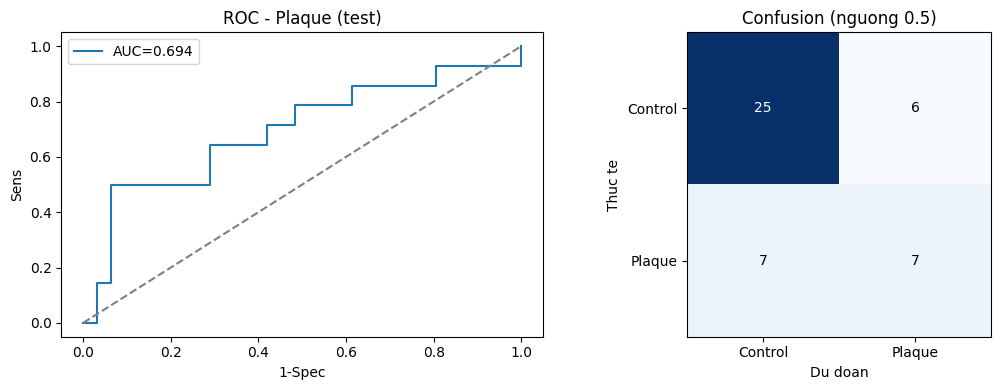

In [67]:
ck = torch.load(OUTPUT_DIR/'best_plaque_model.pt', map_location=DEVICE, weights_only=False)
pm = build_model('plaque'); pm.load_state_dict(ck['model_state_dict'])
_,lva,lte = make_loaders('plaque')
mv = evaluate_task(pm, lva, 'plaque'); mt = evaluate_task(pm, lte, 'plaque')
fpr,tpr,thr = roc_curve(mv['targets'], mv['probs']); best_thr=float(thr[np.argmax(tpr-fpr)])
print(f'Nguong toi uu (val, Youden) = {best_thr:.3f}')
for t,name in [(0.5,'0.5'),(best_thr,f'{best_thr:.2f}')]:
    pred=(np.array(mt['probs'])>=t).astype(int); T=np.array(mt['targets'])
    print(f'[nguong {name}] Sens={recall_score(T,pred,pos_label=1,zero_division=0):.3f} '
          f'Spec={recall_score(T,pred,pos_label=0,zero_division=0):.3f} '
          f'F1={f1_score(T,pred,zero_division=0):.3f}')

fpr2,tpr2,_=roc_curve(mt['targets'], mt['probs']); cm=confusion_matrix(mt['targets'],mt['preds'],labels=[0,1])
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(fpr2,tpr2,label=f"AUC={mt['auc']:.3f}"); ax[0].plot([0,1],[0,1],'--',color='gray')
ax[0].set_xlabel('1-Spec'); ax[0].set_ylabel('Sens'); ax[0].set_title('ROC - Plaque (test)'); ax[0].legend()
im=ax[1].imshow(cm,cmap='Blues')
for i in range(2):
    for j in range(2): ax[1].text(j,i,int(cm[i,j]),ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
ax[1].set_xticks([0,1]); ax[1].set_xticklabels(['Control','Plaque']); ax[1].set_yticks([0,1]); ax[1].set_yticklabels(['Control','Plaque'])
ax[1].set_xlabel('Du doan'); ax[1].set_ylabel('Thuc te'); ax[1].set_title('Confusion (nguong 0.5)')
plt.tight_layout(); plt.show()

## 14 · EDA & kiểm tra toàn vẹn dữ liệu

Anh CSV: 680 | tren dia: 680 | thieu: 0 | thua: 0

Lp(a) TB theo echogenicity (ca plaque):
{'High': 28.4, 'Intermediate': 34.4, 'Low': 42.0}


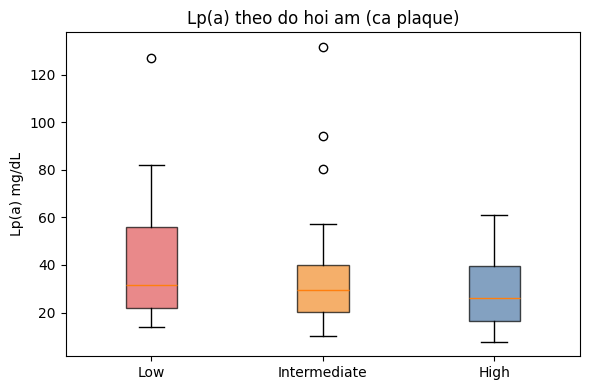

In [68]:
listed=set()
for _,r in df.iterrows():
    for p in str(r[image_list_col]).split(','): listed.add(p.strip())
on_disk={p.name for p in IMAGE_ROOT.rglob('*.png')}
print('Anh CSV:',len(listed),'| tren dia:',len(on_disk),'| thieu:',len(listed-on_disk),'| thua:',len(on_disk-listed))
if echo_col:
    print('\nLp(a) TB theo echogenicity (ca plaque):')
    lpa = find_col(df, ['lp(a)_mg_dl','lp(a)','lpa'])
    if lpa: print(df[df[target_col]==1].groupby(echo_col)[lpa].mean().round(1).to_dict())
    fig,ax=plt.subplots(figsize=(6,4))
    order=[v for v in ['Low','Intermediate','High'] if v in df[echo_col].dropna().unique()]
    data=[df[df[echo_col]==o][lpa].values for o in order]
    bp=ax.boxplot(data,patch_artist=True); ax.set_xticks(range(1,len(order)+1)); ax.set_xticklabels(order)
    for p,c in zip(bp['boxes'],['#e15759','#f28e2b','#4e79a7']): p.set_facecolor(c); p.set_alpha(.7)
    ax.set_ylabel('Lp(a) mg/dL'); ax.set_title('Lp(a) theo do hoi am (ca plaque)'); plt.tight_layout(); plt.show()

## 15 · Baseline chỉ-tabular và Ablation k-fold (Tabular / Image / Fusion)

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

Xraw = df[[c for c in feature_columns]].apply(pd.to_numeric, errors='coerce')
Xraw = Xraw.fillna(Xraw.mean())
if sex_col in feature_columns: Xraw[sex_col] = coerce_sex(df[sex_col]).fillna(0.5)
y = df[target_col].astype(int).values
cvv = StratifiedKFold(5, shuffle=True, random_state=SEED)
auc_tab = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')),
                          Xraw.values, y, cv=cvv, scoring='roc_auc')
print(f'Baseline CHI-TABULAR LogReg (5-fold): AUC = {auc_tab.mean():.3f} +/- {auc_tab.std():.3f}')

Baseline CHI-TABULAR LogReg (5-fold): AUC = 0.710 +/- 0.075


### Ablation k-fold cho nhiệm vụ plaque

In [70]:
class TabOnly(nn.Module):
    def __init__(self, d):
        super().__init__(); self.enc=TabularEncoder(d); self.head=nn.Linear(128,1)
    def forward(self, features, images, image_mask=None): return self.head(self.enc(features)).squeeze(-1)
class ImgOnly(nn.Module):
    def __init__(self):
        super().__init__(); self.enc=SimpleCNNEncoder(); self.pool=AttentionPool(128); self.head=nn.Linear(128,1)
    def forward(self, features, images, image_mask=None):
        B,K,C,H,W=images.shape; emb=self.enc(images.view(B*K,C,H,W)).view(B,K,-1)
        if image_mask is None: image_mask=torch.ones(B,K,device=images.device)
        return self.head(self.pool(emb,image_mask)).squeeze(-1)

def _fit_eval(build, tr_idx, va_idx, epochs=8):
    tr = MultimodalDataset(work.iloc[tr_idx], 'imt', 1); va = MultimodalDataset(work.iloc[va_idx], 'imt', 1)
    ltr=DataLoader(tr,batch_size=BATCH_SIZE,shuffle=True,collate_fn=collate)
    lva=DataLoader(va,batch_size=BATCH_SIZE,shuffle=False,collate_fn=collate)
    m=build().to(DEVICE); opt=torch.optim.AdamW(m.parameters(),lr=1e-3,weight_decay=1e-4); best=-1
    for _ in range(epochs):
        m.train()
        for b in ltr:
            opt.zero_grad(); out=m(b['features'].to(DEVICE),b['images'].to(DEVICE),b['image_mask'].to(DEVICE))
            loss=bce(out,b['label'].to(DEVICE)); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(),1.0); opt.step()
        m.eval(); T,PB=[],[]
        with torch.no_grad():
            for b in lva:
                pb=torch.sigmoid(m(b['features'].to(DEVICE),b['images'].to(DEVICE),b['image_mask'].to(DEVICE)))
                PB+=pb.cpu().tolist(); T+=b['label'].long().cpu().tolist()
        if len(set(T))>1: best=max(best, roc_auc_score(T,PB))
    return best

def run_ablation(k=3, epochs=8):
    skf=StratifiedKFold(k, shuffle=True, random_state=SEED); yv=work[target_col].values
    builders={'Tabular-only':lambda:TabOnly(len(feature_columns)),
              'Image-only':lambda:ImgOnly(),
              'Fusion':lambda:MultimodalTaskModel(len(feature_columns),'binary')}
    print(f"{'Mo hinh':<14}{'plaque AUC (mean+/-std)':>26}")
    for name,b in builders.items():
        aucs=[_fit_eval(b, tr, va, epochs) for tr,va in skf.split(np.arange(len(work)), yv)]
        a=np.array(aucs); print(f'{name:<14}{a.mean():>14.3f} +/- {a.std():.3f}')

run_ablation(k=5, epochs=15)

Mo hinh          plaque AUC (mean+/-std)
Tabular-only           0.720 +/- 0.075
Image-only             0.717 +/- 0.067
Fusion                 0.752 +/- 0.064


## 16 · Ghi chú
* **Per-task models**: mỗi nhiệm vụ có checkpoint riêng chọn theo metric riêng → ổn định hơn multi-task đơn.
* **Chống rò rỉ**: plaque chỉ dùng IMT; echo chỉ trên ca có plaque (3 lớp Low/Int/High).
* **risk_category** rất lệch lớp (≈293/7) → chỉ tham khảo, không nên kết luận mạnh.
* Dữ liệu tổng hợp ⇒ chỉ *proof-of-concept*; cần validate trên siêu âm thật.
